# Subscription Churn: From Prediction to Retention Economics

KKBox churn prediction + retention economics. This notebook builds the
SQL feature mart, runs cohort/survival analysis and hypothesis tests,
trains a temporally validated LightGBM model, calibrates it, explains
it with SHAP, and turns the calibrated probabilities into a
retention-campaign expected value / breakeven analysis.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.candidates import scope_to_renewal_candidates
from src.cohorts import build_cohort_retention
from src.economics import (
    breakeven_conversion_rate,
    campaign_expected_profit,
    scale_to_full_population,
)
from src.feature_mart import build_feature_mart
from src.hypothesis_tests import (
    chi_square_independence,
    correct_pvalues,
    two_proportion_ztest,
)
from src.labels import derive_churn_labels
from src.modeling import (
    FEATURE_COLUMNS,
    brier_before_after,
    calibrate_isotonic,
    evaluate,
    train_lightgbm,
    train_logistic_baseline,
)
from src.sampling import stratified_sample
from src.shap_utils import compute_shap_values
from src.survival import fit_km_by_segment, logrank_pvalue

CUTOFFS = {"train": "2016-11-30", "val": "2016-12-31", "test": "2017-01-31"}
LABEL_HORIZON_DAYS = 30

## 1. Data

Raw KKBox CSVs were converted to Parquet once (`data/interim/`) via
`scripts/download_data.sh` + a one-time DuckDB `COPY ... TO parquet`
pass, casting the dataset's `YYYYMMDD`-integer date columns to real
`DATE`s. `transactions.parquet` merges `transactions.csv` (history
through 2017-02-28) with `transactions_v2.csv` (extends to 2017-03-31)
-- the test-fold cutoff (2017-01-31) needs that extra month of forward
visibility to observe whether a member renews within the 30-day churn
window; `transactions.csv` alone ends exactly on the cutoff itself.

In [2]:
con = duckdb.connect()
con.execute('SET memory_limit="6GB"')
con.execute("SET threads TO 6")
con.execute("SET temp_directory='data/interim/duckdb_tmp'")
con.execute("CREATE VIEW members AS SELECT * FROM read_parquet('data/interim/members.parquet')")
con.execute("CREATE VIEW transactions AS SELECT * FROM read_parquet('data/interim/transactions.parquet')")
con.execute("CREATE VIEW user_logs AS SELECT * FROM read_parquet('data/interim/user_logs.parquet')")

members_df = con.execute("SELECT * FROM members").df()
members_df["registration_init_time"] = pd.to_datetime(members_df["registration_init_time"])
print(f"members: {len(members_df):,} rows")

members: 6,769,473 rows


## 2. EDA: demographics sanity check

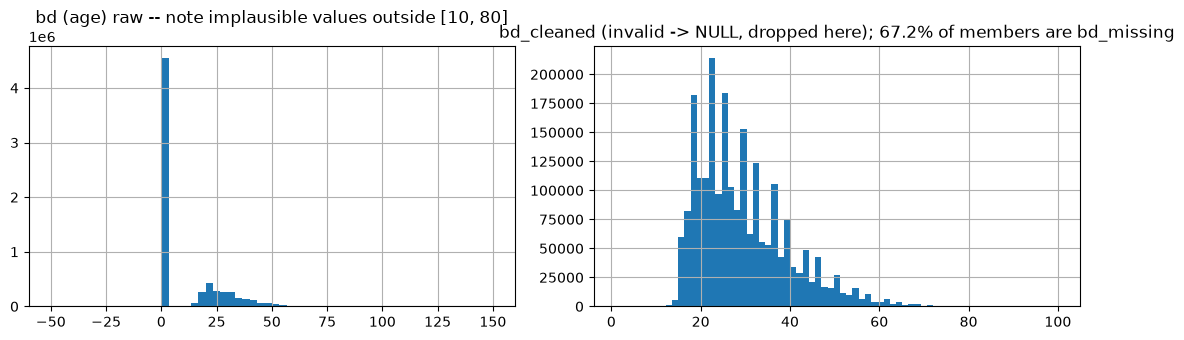

bd_missing share: 67.152% (4,545,866 of 6,769,473 members)


missingness per column:
 gender                    0.654335
msno                      0.000000
city                      0.000000
bd                        0.000000
registered_via            0.000000
registration_init_time    0.000000
dtype: float64


In [3]:
# bd<=0 or bd>100 is not a real age (KKBox's bd field is self-reported
# and mostly garbage/unset at those values) -- rather than clipping it
# into a fake "10 years old" spike, treat it as missing (bd_cleaned =
# NULL) and track it via bd_missing, same as the SQL/pipeline
# demographic-join query below.
bd_missing_mask = (members_df["bd"] <= 0) | (members_df["bd"] > 100)
bd_cleaned = members_df["bd"].where(~bd_missing_mask)
bd_missing_share = bd_missing_mask.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
members_df["bd"].clip(-50, 150).hist(bins=60, ax=axes[0])
axes[0].set_title("bd (age) raw -- note implausible values outside [10, 80]")
bd_cleaned.dropna().hist(bins=71, ax=axes[1])
axes[1].set_title(f"bd_cleaned (invalid -> NULL, dropped here); {bd_missing_share:.1%} of members are bd_missing")
plt.tight_layout()
plt.savefig("data/processed/fig_bd_distribution.png", dpi=100)
plt.show()

print(f"bd_missing share: {bd_missing_share:.3%} ({bd_missing_mask.sum():,} of {len(members_df):,} members)")

missingness = members_df.isna().mean().sort_values(ascending=False)
print("missingness per column:\n", missingness)

In [4]:
official_train = con.execute("SELECT * FROM read_csv_auto('data/raw/train.csv')").df()
print(f"official train.csv (Kaggle, Jan-2017 cutoff): {len(official_train):,} rows, "
      f"churn rate {official_train['is_churn'].mean():.3%}")

official train.csv (Kaggle, Jan-2017 cutoff): 992,931 rows, churn rate 6.392%


## 3. Feature mart + labels for the three temporal cutoffs

Candidate scoping: a member only has a churn/retain decision to make
around a cutoff if their subscription is actually coming up for renewal
then. Restricting to members whose `expire_at_cutoff` falls in
`[cutoff, cutoff + 28 days)` reproduces Kaggle's own `train.csv`
candidate count closely (within ~4%: ~956k candidates here vs.
train.csv's 993k, 95% label agreement on the overlap) -- without it
the population includes everyone with *any* transaction history, most
of them mid-subscription with nothing to decide yet, which inflates
apparent churn to ~50%. Churn rates vary by fold (train: ~7.7%, test:
~3.5%) and run below train.csv's aggregate 6.4% -- see README
Limitations.

In [5]:
tx_all = con.execute("SELECT msno, transaction_date, membership_expire_date, is_cancel FROM transactions").df()
tx_all["transaction_date"] = pd.to_datetime(tx_all["transaction_date"])
tx_all["membership_expire_date"] = pd.to_datetime(tx_all["membership_expire_date"])
print(f"transactions: {len(tx_all):,} rows, {tx_all['transaction_date'].min()} to {tx_all['transaction_date'].max()}")

folds = []
for fold_name, cutoff in CUTOFFS.items():
    mart = build_feature_mart(con, cutoff)
    labels = derive_churn_labels(tx_all, pd.Timestamp(cutoff), label_horizon_days=LABEL_HORIZON_DAYS)
    labels = scope_to_renewal_candidates(labels, pd.Timestamp(cutoff), window_days=28)
    merged = mart.merge(labels[["msno", "is_churn", "expire_at_cutoff"]], on="msno", how="inner")
    merged["fold"] = fold_name
    folds.append(merged)
    print(f"{fold_name} ({cutoff}): {len(merged):,} candidates, churn rate {merged['is_churn'].mean():.3%}")

population = pd.concat(folds, ignore_index=True)
del folds
print(f"combined population: {len(population):,} rows")

# Captured here, BEFORE stratified_sample runs below, so downstream economics
# scaling (scale_to_full_population) reflects the true un-sampled test-fold
# candidate count, not the ~12%-sampled fold size.
full_test_population_size = (population["fold"] == "test").sum()
print(f"full (un-sampled) test-fold population: {full_test_population_size:,} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

transactions: 22,975,416 rows, 2015-01-01 00:00:00 to 2017-03-31 00:00:00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

train (2016-11-30): 842,708 candidates, churn rate 7.644%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

val (2016-12-31): 823,209 candidates, churn rate 4.046%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

test (2017-01-31): 844,114 candidates, churn rate 3.656%
combined population: 2,510,031 rows
full (un-sampled) test-fold population: 844,114 rows


In [6]:
extra = con.execute('''
    SELECT msno, city,
        CASE WHEN bd <= 0 OR bd > 100 THEN NULL ELSE bd END AS bd_cleaned,
        (bd <= 0 OR bd > 100) AS bd_missing,
        gender, registered_via
    FROM members
''').df()
population = population.merge(extra, on="msno", how="left")
population.head()

,msno,tenure_days,is_auto_renew,payment_method_id,plan_list_price,actual_amount_paid,discount_flag,num_transactions_last_90d,num_cancels_lifetime,active_days_last_30,...,activity_trend_30d,days_since_last_log,is_churn,expire_at_cutoff,fold,city,bd_cleaned,bd_missing,gender,registered_via
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,906,1,41,99,99,False,1,0.0,14,...,NaN,1,0,2016-12-15,train,1,<NA>,True,None,7
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,2204,1,39,149,149,False,2,0.0,29,...,0.729733,1,0,2016-12-19,train,15,26,False,male,9
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,795,1,41,149,149,False,3,0.0,17,...,1.900857,1,0,2016-12-26,train,1,<NA>,True,None,7
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,260,1,41,149,149,False,3,0.0,26,...,1.017150,1,0,2016-12-15,train,18,21,False,male,7
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,1774,1,39,149,149,False,2,0.0,20,...,0.854889,2,0,2016-12-23,train,22,32,False,male,9


## 4. Stratified sample to 300k rows (runtime tradeoff)

In [7]:
population["has_recent_activity"] = population["active_days_last_30"] > 0
sample = stratified_sample(population, "has_recent_activity", sample_size=300_000, random_state=42)
sample.to_parquet("data/processed/sampled_population.parquet", index=False)
print(f"sampled population: {len(sample):,} rows")
print(sample.groupby("fold")["is_churn"].agg(["count", "mean"]))

sampled population: 300,000 rows
        count      mean
fold                   
test   100794  0.035726
train  100542  0.078087
val     98664  0.038839


## 5. Cohort retention

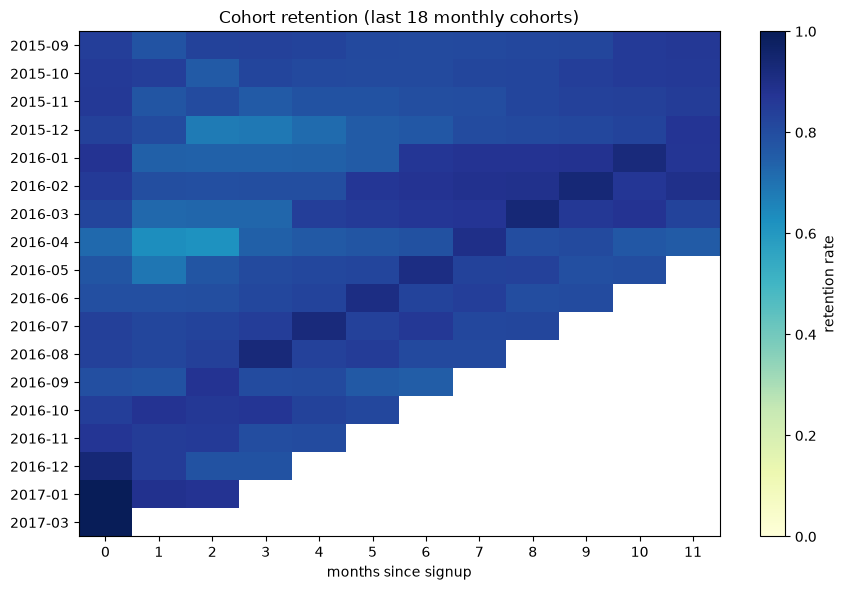

In [8]:
tx_all["month"] = tx_all["transaction_date"].values.astype("datetime64[M]")
active_periods = tx_all[["msno", "month"]].drop_duplicates().rename(columns={"month": "period"})

# Scope the retention denominator to the renewal-candidate population
# (not every KKBox registrant ever) -- otherwise month-0 retention reads
# far below 100% because the denominator includes members who never had
# a subscription to retain in the first place.
candidate_msnos = population["msno"].unique()
members_df = members_df[members_df["msno"].isin(candidate_msnos)]

# Bound the observable months_since_signup window on both edges: the
# transactions data has a start and an end, so a cohort's early months
# can be unobserved (left-censored, if the cohort registered before the
# data's coverage begins) just as its late months can be (the data
# hasn't caught up yet). Cells outside [min, max] stay NaN rather than
# being zero-filled as if they were observed-and-empty.
data_start = tx_all["transaction_date"].min()
data_end = tx_all["transaction_date"].max()
cohort_retention = build_cohort_retention(
    members_df,
    active_periods,
    max_observable_month=lambda cohort_month: (
        (data_end.to_period("M") - cohort_month).n
    ),
    min_observable_month=lambda cohort_month: max(
        0, (data_start.to_period("M") - cohort_month).n
    ),
)
cohort_retention.to_parquet("data/processed/cohort_retention.parquet")

recent_cohorts = cohort_retention.tail(18).iloc[:, :12]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(recent_cohorts.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_yticks(range(len(recent_cohorts.index)))
ax.set_yticklabels([str(p) for p in recent_cohorts.index])
ax.set_xticks(range(recent_cohorts.shape[1]))
ax.set_xlabel("months since signup")
ax.set_title("Cohort retention (last 18 monthly cohorts)")
plt.colorbar(im, ax=ax, label="retention rate")
plt.tight_layout()
plt.savefig("data/processed/fig_cohort_retention.png", dpi=100)
plt.show()

## 6. Survival analysis (Kaplan-Meier + log-rank), test-fold snapshot

log-rank is_auto_renew (1 vs 0): p=0
log-rank registered_via (7 vs 9): p=3.606e-19


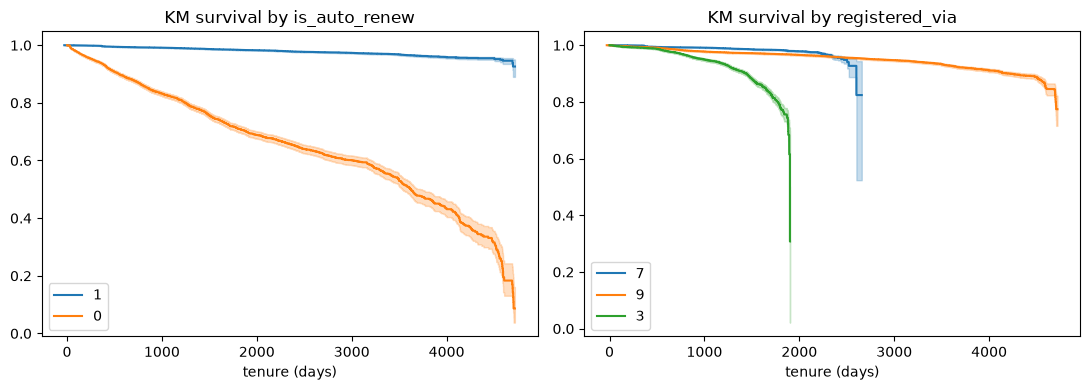

In [9]:
test_fold = sample[sample["fold"] == "test"].merge(
    members_df[["msno", "registration_init_time"]], on="msno", how="left"
)
# Duration is time-to-event, tied to the same renewal decision
# is_churn describes -- not an unrelated calendar-tenure snapshot.
test_fold["duration_days"] = (test_fold["expire_at_cutoff"] - test_fold["registration_init_time"]).dt.days

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
survival_pvalues = {}
for ax, segment_col in zip(axes, ["is_auto_renew", "registered_via"]):
    seg = test_fold[segment_col].astype("string")
    top_groups = seg.value_counts().head(3).index.tolist()
    fitters = fit_km_by_segment(
        test_fold["duration_days"], test_fold["is_churn"],
        seg.where(seg.isin(top_groups)),
    )
    for label, kmf in fitters.items():
        kmf.plot_survival_function(ax=ax)
    ax.set_title(f"KM survival by {segment_col}")
    ax.set_xlabel("tenure (days)")
    if len(top_groups) >= 2:
        p = logrank_pvalue(test_fold["duration_days"], test_fold["is_churn"], seg, top_groups[0], top_groups[1])
        survival_pvalues[segment_col] = p
        print(f"log-rank {segment_col} ({top_groups[0]} vs {top_groups[1]}): p={p:.4g}")
plt.tight_layout()
plt.savefig("data/processed/fig_survival_curves.png", dpi=100)
plt.show()

## 7. Hypothesis testing with Benjamini-Hochberg correction

In [10]:
p_values, test_labels = [], []

auto_renew_churn = test_fold.groupby("is_auto_renew")["is_churn"].agg(["sum", "count"])
if len(auto_renew_churn) == 2:
    _, p = two_proportion_ztest(tuple(auto_renew_churn["sum"]), tuple(auto_renew_churn["count"]))
    p_values.append(p); test_labels.append("auto_renew_vs_churn")

reg_via_table = pd.crosstab(test_fold["registered_via"], test_fold["is_churn"])
if reg_via_table.shape[0] > 1:
    _, p = chi_square_independence(reg_via_table)
    p_values.append(p); test_labels.append("registered_via_vs_churn")

price_tercile = pd.qcut(test_fold["plan_list_price"], 3, labels=["low", "mid", "high"], duplicates="drop")
price_table = pd.crosstab(price_tercile, test_fold["is_churn"])
if price_table.shape[0] > 1:
    _, p = chi_square_independence(price_table)
    p_values.append(p); test_labels.append("price_tercile_vs_churn")

reject_flags = correct_pvalues(p_values)
hypothesis_results = pd.DataFrame({"test": test_labels, "p_value": p_values, "significant_after_BH": reject_flags})
hypothesis_results.to_parquet("data/processed/hypothesis_test_results.parquet", index=False)
hypothesis_results

,test,p_value,significant_after_BH
0,auto_renew_vs_churn,0.0,True
1,registered_via_vs_churn,0.0,True
2,price_tercile_vs_churn,0.0,True


## 8. Modeling: temporal LightGBM + isotonic calibration

Train/val/test come from three *non-overlapping monthly cutoffs*
(Nov/Dec/Jan), not a random split -- a random split would leak future
activity/renewal patterns backward into training.

In [11]:
train_df = sample[sample["fold"] == "train"]
val_df = sample[sample["fold"] == "val"]
test_df = sample[sample["fold"] == "test"]
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {len(df):,} rows, churn rate {df['is_churn'].mean():.3%}")

model = train_lightgbm(train_df, val_df)
metrics = evaluate(model, test_df)
print(f"test PR-AUC={metrics['pr_auc']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

train: 100,542 rows, churn rate 7.809%
val: 98,664 rows, churn rate 3.884%
test: 100,794 rows, churn rate 3.573%
[LightGBM] [Info] Number of positive: 7851, number of negative: 92691
[LightGBM] [Info] Total Bins 1415
[LightGBM] [Info] Number of data points in the train set: 100542, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.078087 -> initscore=-2.468630
[LightGBM] [Info] Start training from score -2.468630


test PR-AUC=0.3658  ROC-AUC=0.8700


Baseline: does a plain logistic regression on the same features beat this?

In [12]:
baseline = train_logistic_baseline(train_df)
baseline_metrics = evaluate(baseline, test_df)
print(f"baseline PR-AUC={baseline_metrics['pr_auc']:.4f}  ROC-AUC={baseline_metrics['roc_auc']:.4f}")

baseline PR-AUC=0.2924  ROC-AUC=0.8442


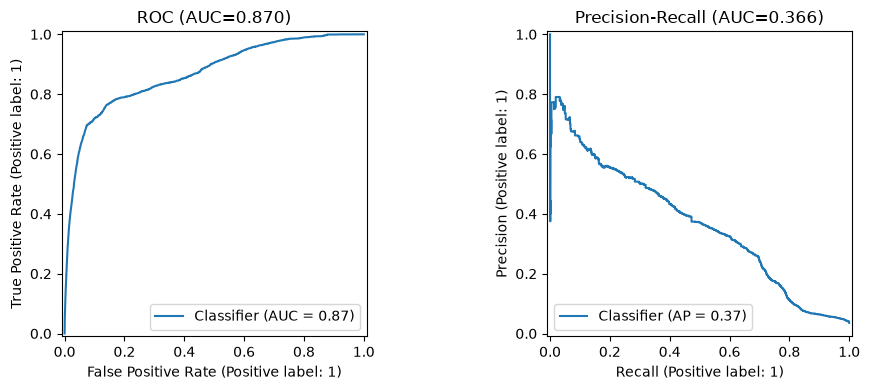

,sum,count,pct_of_total_churn,cum_pct_of_total_churn
decile,,,,
9,2515,10059,0.698417,0.698417
8,313,10094,0.086920,0.785337
7,109,10085,0.030269,0.815607
6,111,10080,0.030825,0.846432
5,179,10070,0.049708,0.896140
4,159,10087,0.044154,0.940294
3,114,10063,0.031658,0.971952
2,58,10096,0.016107,0.988059
1,41,10028,0.011386,0.999445


In [13]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

p_churn_raw = model.predict_proba(test_df[FEATURE_COLUMNS])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(test_df["is_churn"], p_churn_raw, ax=axes[0])
axes[0].set_title(f"ROC (AUC={metrics['roc_auc']:.3f})")
PrecisionRecallDisplay.from_predictions(test_df["is_churn"], p_churn_raw, ax=axes[1])
axes[1].set_title(f"Precision-Recall (AUC={metrics['pr_auc']:.3f})")
plt.tight_layout()
plt.savefig("data/processed/fig_pr_roc.png", dpi=100)
plt.show()

decile = pd.DataFrame({"p_churn": p_churn_raw, "is_churn": test_df["is_churn"].values})
decile["decile"] = pd.qcut(decile["p_churn"], 10, labels=False, duplicates="drop")
lift_table = decile.groupby("decile")["is_churn"].agg(["sum", "count"])
lift_table["pct_of_total_churn"] = lift_table["sum"] / lift_table["sum"].sum()
lift_table = lift_table.sort_index(ascending=False)
lift_table["cum_pct_of_total_churn"] = lift_table["pct_of_total_churn"].cumsum()
lift_table

## 9. Calibration

Brier before=0.0833  after=0.0271


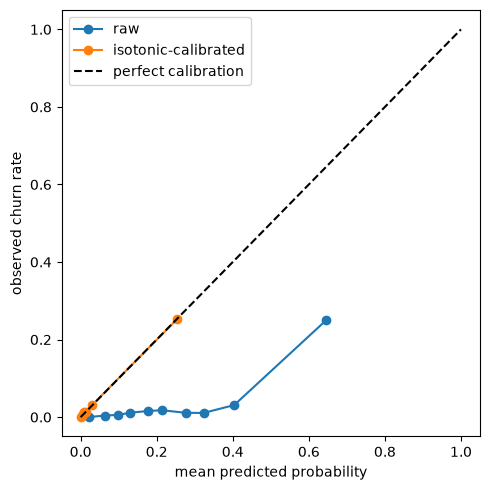

In [14]:
calibrated = calibrate_isotonic(model, val_df)
brier = brier_before_after(model, calibrated, test_df)
print(f"Brier before={brier['brier_before']:.4f}  after={brier['brier_after']:.4f}")

p_churn_calibrated = calibrated.predict_proba(test_df[FEATURE_COLUMNS])[:, 1]

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5, 5))
for label, proba in [("raw", p_churn_raw), ("isotonic-calibrated", p_churn_calibrated)]:
    frac_pos, mean_pred = calibration_curve(test_df["is_churn"], proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed churn rate")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/fig_calibration.png", dpi=100)
plt.show()

## 10. SHAP interpretation

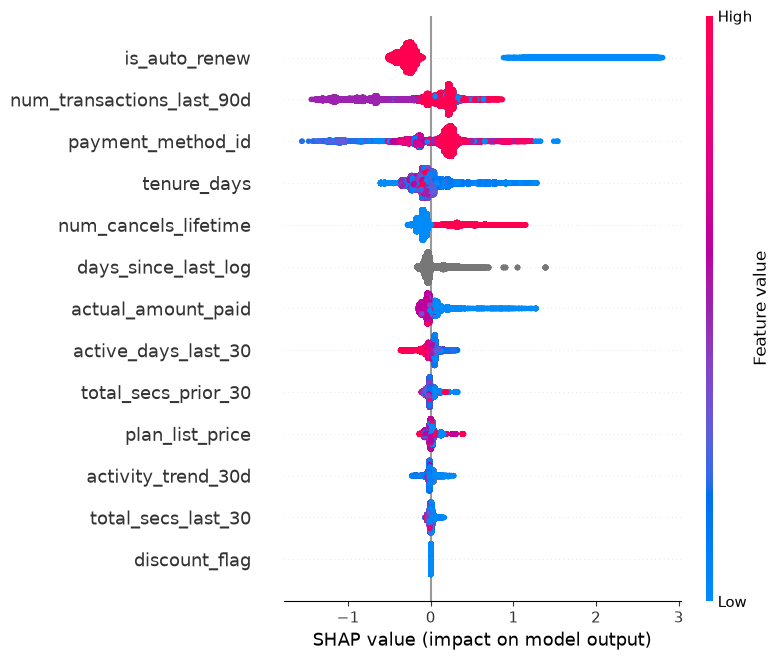

is_auto_renew                0.490528
num_transactions_last_90d    0.353893
payment_method_id            0.283603
tenure_days                  0.157649
num_cancels_lifetime         0.152102
dtype: float64

In [15]:
shap_values = compute_shap_values(model, test_df[FEATURE_COLUMNS])
shap.summary_plot(shap_values, test_df[FEATURE_COLUMNS], show=False)
plt.tight_layout()
plt.savefig("data/processed/fig_shap_summary.png", dpi=100)
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLUMNS).sort_values(ascending=False)
mean_abs_shap.head(5)

## 11. Retention-campaign economics

Sweeping the contact-volume threshold (top-k% by calibrated churn risk)
against `src/economics.py`'s EV formula finds the profit-maximizing
contact volume and its breakeven conversion rate -- the number this
project's thesis says the business should actually be tracking.

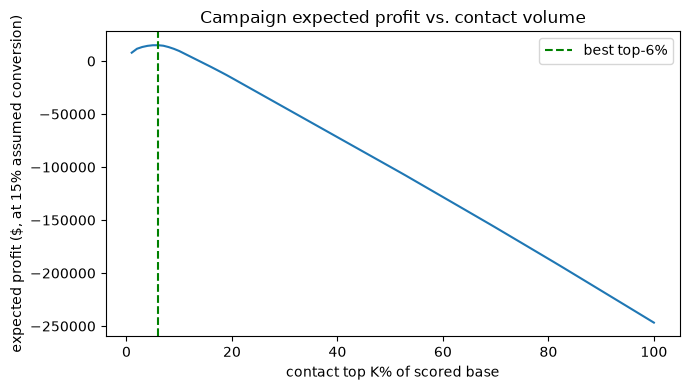

best contact volume: top 6% of scored base
expected profit at that volume (assuming 15% conversion): $14,967
breakeven conversion rate at that volume: 8.2%


In [16]:
ARPU, AVG_LIFETIME_MONTHS, CONTACT_COST, ASSUMED_CONVERSION = 4.99, 21, 3.0, 0.15

p_series = pd.Series(p_churn_calibrated, index=test_df.index)
ks = np.arange(0.01, 1.01, 0.01)
profits = [
    campaign_expected_profit(p_series, k, ASSUMED_CONVERSION, ARPU, AVG_LIFETIME_MONTHS, CONTACT_COST)
    for k in ks
]
best_idx = int(np.argmax(profits))
best_k, best_profit = ks[best_idx], profits[best_idx]
breakeven = breakeven_conversion_rate(p_series, best_k, ARPU, AVG_LIFETIME_MONTHS, CONTACT_COST)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks * 100, profits)
ax.axvline(best_k * 100, color="green", linestyle="--", label=f"best top-{best_k:.0%}")
ax.set_xlabel("contact top K% of scored base")
ax.set_ylabel(f"expected profit ($, at {ASSUMED_CONVERSION:.0%} assumed conversion)")
ax.set_title("Campaign expected profit vs. contact volume")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/fig_campaign_economics.png", dpi=100)
plt.show()

print(f"best contact volume: top {best_k:.0%} of scored base")
print(f"expected profit at that volume (assuming {ASSUMED_CONVERSION:.0%} conversion): ${best_profit:,.0f}")
print(f"breakeven conversion rate at that volume: {breakeven:.1%}")

In [17]:
scenarios = []
for label, lifetime_months, margin_rate in [
    ("21mo revenue (original assumption)", 21, 1.0),
    ("12mo revenue (target-group-adjusted lifetime)", 12, 1.0),
    ("12mo margin at 40% margin_rate", 12, 0.4),
    ("6mo revenue", 6, 1.0),
]:
    sample_profit = campaign_expected_profit(
        p_series, best_k, conversion_rate=0.15, arpu=4.99,
        avg_lifetime_months=lifetime_months, contact_cost=3.0, margin_rate=margin_rate,
    )
    full_profit = scale_to_full_population(
        sample_profit, sample_size=len(p_series), full_population_size=full_test_population_size,
    )
    scenarios.append({"scenario": label, "sample_profit": sample_profit, "full_population_profit": full_profit})

scenario_table = pd.DataFrame(scenarios)
print(scenario_table.to_string(index=False))

                                     scenario  sample_profit  full_population_profit
           21mo revenue (original assumption)   14967.303132           125345.855071
12mo revenue (target-group-adjusted lifetime)     776.744647             6504.960919
               12mo margin at 40% margin_rate  -10575.702141           -88567.754403
                                  6mo revenue   -8683.627677           -72722.301849


**Uplift caveat:** this EV model assumes the campaign's `conversion_rate` applies uniformly to everyone contacted. In practice, a retention offer's effect (uplift) varies by member -- some would've stayed anyway, some can't be saved regardless of the offer. Properly targeting contact volume would use an uplift model (e.g. two-model or a causal-tree approach trained on historical campaign A/B data) to target *persuadable* members, not just *highest-churn-risk* ones. Not implemented here -- flagged as the natural next step, since it changes who gets contacted, not just the breakeven math.

## 12. Write scored feature mart (feeds the Streamlit dashboard)

In [18]:
scored = test_df.copy()
scored["p_churn_raw"] = p_churn_raw
scored["p_churn_calibrated"] = p_churn_calibrated
scored.to_parquet("data/processed/scored_feature_mart.parquet", index=False)
print(f"wrote {len(scored):,} rows to data/processed/scored_feature_mart.parquet")

wrote 100,794 rows to data/processed/scored_feature_mart.parquet
